**AZ Watch** is a popular video streaming platform specialized in educational content, where creators publish online video tutorials and lessons about any topic, from speaking a new language to cooking to learning to play a musical instrument.

Their next goal is to leverage AI-driven solutions to analyze and make predictions about their subscribers and improve their marketing strategy around attracting new subscribers and retaining current ones. This project uses machine learning to predict subscribers likely to churn and find customer segments. This may help AZ Watch find interesting usage patterns to build subscriber personas in future marketing plans!

![Woman working on multiple screens](marketinganalytics.jpg)


The `data/AZWatch_subscribers.csv` **dataset** contains information about subscribers and their status over the last year:

|Column name|Description|
|-----------|-----------|
|`subscriber_id`|The unique identifier of each subscriber user|
|`age_group`|The subscriber's age group|
|`engagement_time`|Average time (in minutes) spent by the subscriber per session|
|`engagement_frequency`|Average weekly number of times the subscriber logged in the platform (sessions) over a year period|
|`subscription_status`|Whether the user remained subscribed to the platform by the end of the year period (subscribed), or unsubscribed and terminated her/his services (churned)|

Carefully observe and analyze the features in the dataset, asking yourself if there are any **categorical attributes** requiring pre-processing?

The subscribers dataset from the `data/AZWatch_subscribers.csv` file is already being loaded and split into training and test sets for you:

In [ ]:
# Import the necessary modules
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
import seaborn as sns
from matplotlib import pyplot as plt

# Specify the file path of your CSV file
file_path = "Data/AZWatch_subscribers.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

In [ ]:
# Start your code here! Use as many cells as you like!
# Data exploration
# Exploración de datos
print(df.head())

   subscriber_id    age_group  ...  engagement_frequency  subscription_status
0          14451        18-34  ...                     7           subscribed
1          18386     under 18  ...                    12           subscribed
2          12305  35 and over  ...                     4              churned
3          17546        18-34  ...                    15           subscribed
4          15399        18-34  ...                    20           subscribed

[5 rows x 5 columns]


In [127]:
df['engagement_time'].head()

0     5.55
1     5.12
2     4.25
3     8.54
4    12.12
Name: engagement_time, dtype: float64

In [128]:
print(df.dtypes)

subscriber_id             int64
age_group                object
engagement_time         float64
engagement_frequency      int64
subscription_status      object
dtype: object


In [ ]:
# Skew
# Sesgos en el dataframe
print(df.skew())

subscriber_id          -0.018876
engagement_time         0.464665
engagement_frequency    0.743829
dtype: float64


In [ ]:
# Correlation
# Correlación en el dataframe para detectar multicolinealidad
print(df.corr())

                      subscriber_id  engagement_time  engagement_frequency
subscriber_id              1.000000        -0.000955              0.022341
engagement_time           -0.000955         1.000000              0.317209
engagement_frequency       0.022341         0.317209              1.000000


In [ ]:
# Suma de valores null
print(df.isna().sum())

subscriber_id           0
age_group               0
engagement_time         0
engagement_frequency    0
subscription_status     0
dtype: int64


In [ ]:
# Getting numerical values
# Codificar columna a numérico (binario)
df['subscription_status']= df['subscription_status'].replace({'subscribed': 0, 'churned': 1})
df['subscription_status'].value_counts()

0    553
1    447
Name: subscription_status, dtype: int64

In [ ]:
# Setting category columns
# Definir columnas categóricas
df['age_group']= df['age_group'].astype('category')
print(df.dtypes)

subscriber_id              int64
age_group               category
engagement_time          float64
engagement_frequency       int64
subscription_status        int64
dtype: object


In [ ]:
# Applying StandardScaler
# Normalizar variables numéricas
df_normalized= StandardScaler().fit_transform(df[['engagement_time', 'engagement_frequency']])
print(df_normalized.mean())

1.0658141036401502e-16


In [135]:
print(df_normalized.shape)

(1000, 2)


In [ ]:
# Creación de dataframe con variables normalizadas
df2= pd.DataFrame(df_normalized, 
                  columns= ['engagement_time_scaled', 'engagement_frequency_scaled'])
print(df2.head())

   engagement_time_scaled  engagement_frequency_scaled
0               -0.228621                    -0.477723
1               -0.384656                     0.324364
2               -0.700355                    -0.958975
3                0.856369                     0.805616
4                2.155453                     1.607703


In [137]:
print(df.shape)

(1000, 5)


In [ ]:
# Merging dataframes
# Unión de los valores normalizados con el dataframe original
df3= df.merge(df2, how= 'inner', left_index= True, right_index= True)
print(df3.shape)

(1000, 7)


In [ ]:
# Removing duplicated columns
# Eliminar columnas duplicadas sin escalar
df3.drop(columns= ['engagement_time', 'engagement_frequency'], inplace= True)
print(df3.head())

   subscriber_id  ... engagement_frequency_scaled
0          14451  ...                   -0.477723
1          18386  ...                    0.324364
2          12305  ...                   -0.958975
3          17546  ...                    0.805616
4          15399  ...                    1.607703

[5 rows x 5 columns]


In [ ]:
# Separates predictor variables from class label
# Separación de variables
X= df3.drop(['subscriber_id', 'subscription_status'], axis= 1)
y= df3.subscription_status

# One-hot encoding
X= pd.get_dummies(X, columns= ['age_group'], drop_first= True, dtype= int)

# Splitting into training and test sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=.2, random_state=42)

In [ ]:
print(X_train.head())

     engagement_time_scaled  ...  age_group_under 18
29                -0.428201  ...                   0
535               -1.237407  ...                   0
695               -0.547949  ...                   0
557                0.286659  ...                   1
836                0.254000  ...                   0

[5 rows x 4 columns]


In [ ]:
# X_train, X_test shapes
# Comprobar la proporción de variables
print((len(X_train)/len(df.index)) * 100)
print((len(X_test)/len(df.index)) * 100)

80.0
20.0


In [ ]:
# model1 Logistic Regression
model1= LogisticRegression()
model1.fit(X_train, y_train)
y_predict= model1.predict(X_test)
score1= model1.score(X_test, y_test)
print(score1)

0.925


In [ ]:
# model2 Decision Tree Classifier
model2= DecisionTreeClassifier()
model2.fit(X_train, y_train)
y_predict2= model2.predict(X_test)
score2= model2.score(X_test, y_test)
print(score2)

0.87


In [ ]:
# model3 Random Forest Classifier
model3= RandomForestClassifier()
model3.fit(X_train, y_train)
y_predict3= model3.predict(X_test)
score3= model3.score(X_test, y_test)
print(score3)

0.895


In [ ]:
# Best accuracy score
# Almacenar el Accuracy score más alto de los tres modelos realizados arriba
score= score1

In [ ]:
# model1 Confusion matrix
# Matriz de Confusión del modelo de Regresión logística
cm= confusion_matrix(y_test, y_predict)
print(cm)

[[101   8]
 [  7  84]]


In [148]:
X.head()

,engagement_time_scaled,engagement_frequency_scaled,age_group_35 and over,age_group_under 18
0,-0.228621,-0.477723,0,0
1,-0.384656,0.324364,0,1
2,-0.700355,-0.958975,1,0
3,0.856369,0.805616,0,0
4,2.155453,1.607703,0,0


In [ ]:
# K-means Clustering method
# Aplicación del método del 'Codo' para obtener el número óptimo de clusters para el algoritmo K-means
sse= {}
for k in range(1, 11):
    kmeans= KMeans(n_clusters= k, random_state= 333)
    kmeans.fit(X)
    sse[k]= kmeans.inertia_

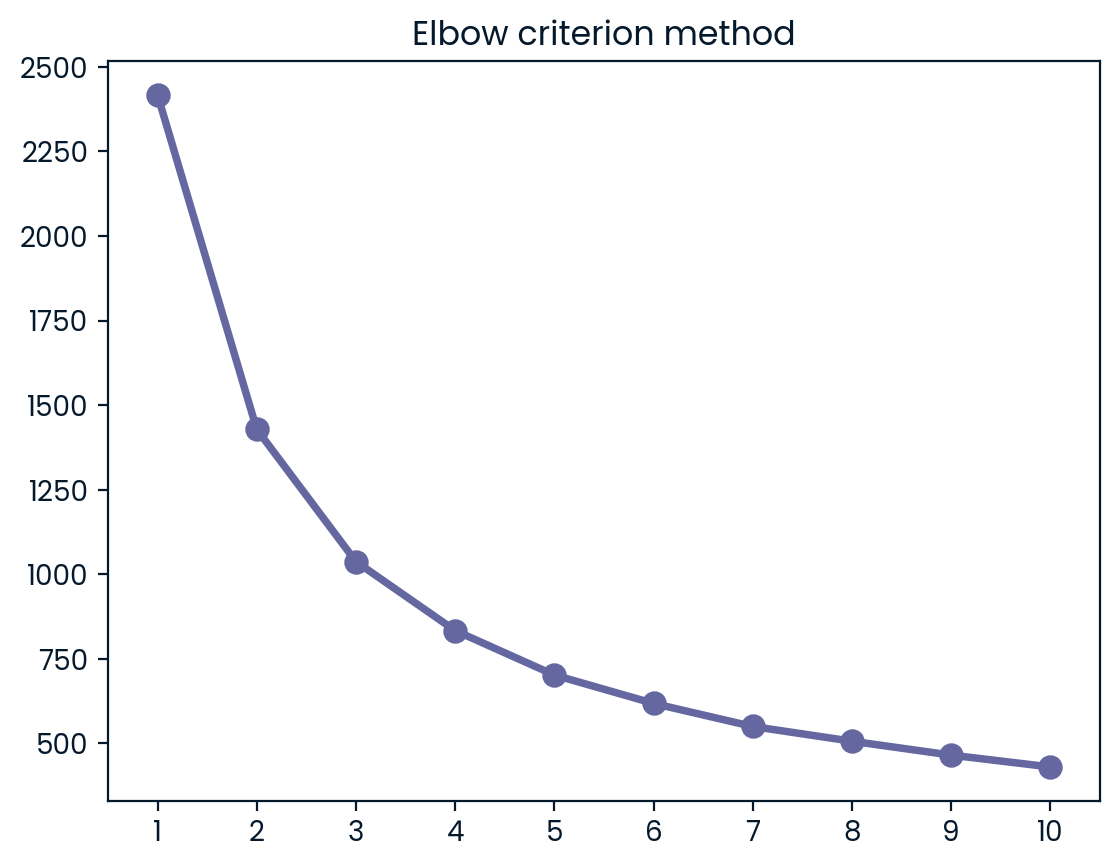

In [150]:
plt.title('Elbow criterion method')
sns.pointplot(x= list(sse.keys()), y= list(sse.values()))
plt.show()


In [ ]:
# K-means Clustering method
# Definición de + 1 cluster en el modelo y obtención de etiquetas
kmeans1= KMeans(n_clusters= 4, random_state= 1)
kmeans1.fit(X)
cluster_labels= kmeans1.labels_

In [ ]:
# Segmentation dataframe
# Creación de un dataframe segmentado, cada etiqueta es un cluster
segmentation= df.assign(Cluster= cluster_labels)

In [153]:
print(segmentation.head())

   subscriber_id    age_group  ...  subscription_status  Cluster
0          14451        18-34  ...                    0        0
1          18386     under 18  ...                    0        0
2          12305  35 and over  ...                    1        3
3          17546        18-34  ...                    0        2
4          15399        18-34  ...                    0        2

[5 rows x 6 columns]


In [ ]:
# Column renamed for the exercise
# Renombrar columna cluster_id
segmentation= segmentation.rename(columns= {'Cluster': 'cluster_id'})
print(segmentation.head())

   subscriber_id    age_group  ...  subscription_status  cluster_id
0          14451        18-34  ...                    0           0
1          18386     under 18  ...                    0           0
2          12305  35 and over  ...                    1           3
3          17546        18-34  ...                    0           2
4          15399        18-34  ...                    0           2

[5 rows x 6 columns]


In [155]:
print(X.columns)

Index(['engagement_time_scaled', 'engagement_frequency_scaled',
       'age_group_35 and over', 'age_group_under 18'],
      dtype='object')


In [ ]:
# Averages per cluster
# Promedio de las variables numéricas por cluster
analysis= segmentation.groupby('cluster_id').agg({'engagement_time': 'mean',
                                                         'engagement_frequency':
                                                         'mean'}).round()
print(analysis)

            engagement_time  engagement_frequency
cluster_id                                       
0                       6.0                   6.0
1                       6.0                  18.0
2                      10.0                  11.0
3                       3.0                   5.0


In [ ]:
# Best Accuracy score 
print(score)

0.925


<b>Actividades:</b>
- Preparación de los datos.
- Normalizar variables numéricas.
- Dividir los datos en variables de entrenamiento y prueba (20% test).
- Aplicación de tres modelos de clasificación de Scikit-Learn.
- Almacenar en una variable Score el Accuracy Score más alto obtenido en los modelos.
- Generar matriz de confusión.
- Aplicación de algoritmo K-means.
- Agrupar engagement_time y engagement_frequency por id de cluster.

<b>Conclusiones:</b>
- Modelo de Regresión Logística:
    - Predijo 92 % de los datos.
    - Permanecen 101 suscriptores, 84 cancelan el servicio.<br><br>
- Agrupación por id de cluster:

| Cluster | Prom. minutos por sesión | Prom. de sesiones semanales durante un año |
| :------------ | :-----------: | :------------: |
| 0 | 6 | 6 |
| 1 | 6 | 18 |
| 2 | 10 | 11 |
| 3 | 3 | 5 |